# API Key 확인

In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [4]:
#기존 캐시된 키 강제 제거
if 'OPENAI_API_KEY' in os.environ:
    del os.environ['OPENAI_API_KEY']

In [5]:
from dotenv import load_dotenv
import os

load_dotenv()

OPENAI_API_KEY = os.environ['OPENAI_API_KEY']
#PINECONE_API_KEY = os.environ['PINECONE_API_KEY']

print("API 키 로드 완료")
print(f"OpenAI Key: {OPENAI_API_KEY[:10]}...")

API 키 로드 완료
OpenAI Key: sk-proj-00...


In [6]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [7]:
# Step 2 : LCEL 기본 체인 동작 확인
from dotenv import load_dotenv
load_dotenv()

True

prompt > LLM(ChatOpenAI) > output_parsers

In [8]:
text = "{topic}에 대한 한 문장으로 설명해줘"

In [9]:
llm = ChatOpenAI(model="gpt-4o-mini")
prompt = PromptTemplate.from_template(text)
output_parsers = StrOutputParser()

In [10]:
chain = prompt | llm | output_parsers

In [11]:
chain

PromptTemplate(input_variables=['topic'], input_types={}, partial_variables={}, template='{topic}에 대한 한 문장으로 설명해줘')
| ChatOpenAI(profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000002185D09A630>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000002185D633B90>, root_client=<openai.OpenAI object at 0x000002185D09A480>, root_async_clie

In [12]:
result = chain.invoke({"topic": "랭체인"})
result

'랭체인(LangChain)은 자연어 처리(NLP)와 AI 모델을 활용하여 대화형 애플리케이션과 데이터 흐름을 통합하는 데 도움을 주는 프레임워크입니다.'

In [13]:
message = [
  ("system", "당신은 세계 최고의 펀드메니저입니다."),
  ("human", "2026년 대한민국에서 유망한 상장사 기업 5개 추천해주세요."),
]

In [14]:
res = llm.invoke(message)
res

AIMessage(content='2026년의 시장 동향을 예측하기는 어렵지만, 대한민국에서 유망할 가능성이 있는 산업과 기업들을 기반으로 다음과 같은 5개의 상장사를 추천합니다. 이 기업들은 기술 혁신, 글로벌 시장 확장, 그리고 지속 가능한 발전 등을 통해 성장 가능성이 높습니다.\n\n1. **삼성전자 (005930)**: 세계적인 반도체 및 전자기기 제조업체로, AI, 5G, 전장 부품 등 다양한 분야에서 발전을 추구하고 있습니다.\n\n2. **LG화학 (051910)**: 배터리, 친환경 소재 등 지속 가능한 사업 모델로의 전환을 강화하고 있으며, 전기차용 배터리 시장에서 성장 가능성이 큽니다.\n\n3. **SK하이닉스 (000660)**: 메모리 반도체 시장에서 강력한 입지를 보유하고 있으며, 데이터센터 및 AI 관련 수요 증가에 따라 성장 잠재력이 큽니다.\n\n4. **Naver (035420)**: 온라인 플랫폼으로서 검색엔진 뿐만 아니라 클라우드 서비스, 광고, 전자상거래 등 다양한 분야에서 수익을 다각화하고 있습니다.\n\n5. **카카오 (035720)**: 메신저 서비스뿐 아니라 게임, 콘텐츠, 금융 서비스로 사업 영역을 확장하고 있으며, 디지털 경제에서의 입지가 계속해서 강화될 것으로 보입니다.\n\n투자 결정을 내리기 전, 각 기업의 재무 상태와 시장 동향을 면밀히 분석하시기 바랍니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 328, 'prompt_tokens': 42, 'total_tokens': 370, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'a

# LangChain Agent 실습

In [15]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain.agents import create_agent   # LangChain 1.x
from langgraph.prebuilt import create_react_agent

In [16]:
@tool
def add(a:float, b:float) -> float:
    """두 숫자를 더합니다."""
    return a + b

In [17]:
@tool
def multiply(a:float, b:float) -> float:
    """두 숫자를 곱합니다."""
    return a * b

In [18]:
tools = [add, multiply] 

In [19]:
agent = create_react_agent(
  prompt = "당신은 계산을 도와주는 어시스턴트입니다.",
  model = llm,
  tools = tools
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_20912\3823417671.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


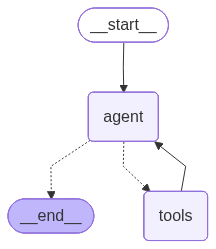

In [20]:
agent

In [21]:
result = agent.invoke({
  "messages": [{"role":"user", "content": "3 더하기 5는 얼마입니까? 그리고 다시 7을 곱하면 어떻게 될까요?"}]
})
result

{'messages': [HumanMessage(content='3 더하기 5는 얼마입니까? 그리고 다시 7을 곱하면 어떻게 될까요?', additional_kwargs={}, response_metadata={}, id='a29d3560-247a-44f3-ace1-e97396f584e0'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 107, 'total_tokens': 157, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_17903ecff9', 'id': 'chatcmpl-DSAzcatVPyV0aUK0RpTGGuJdHvXCM', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d6a79-03da-75c1-b7cd-0c3db76e12d8-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 5}, 'id': 'call_JDJLqHZ8MtIwVzSD8YkMkIlk', 'type': 'tool_call'}, {'name': 'multiply', 'args': {'a': 8, 'b': 7}, 'id': 'call_qClCWM

In [22]:
for msg in result["messages"]:
    print(f"[{msg.__class__.__name__}] {msg.content[:80] if msg.content else '(tool call)'}")

[HumanMessage] 3 더하기 5는 얼마입니까? 그리고 다시 7을 곱하면 어떻게 될까요?
[AIMessage] (tool call)
[ToolMessage] 8.0
[ToolMessage] 56.0
[AIMessage] 3 더하기 5는 8입니다. 그리고 그 결과에 7을 곱하면 56이 됩니다.


In [23]:
print(type(result))
print(result)


<class 'dict'>
{'messages': [HumanMessage(content='3 더하기 5는 얼마입니까? 그리고 다시 7을 곱하면 어떻게 될까요?', additional_kwargs={}, response_metadata={}, id='a29d3560-247a-44f3-ace1-e97396f584e0'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 107, 'total_tokens': 157, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_17903ecff9', 'id': 'chatcmpl-DSAzcatVPyV0aUK0RpTGGuJdHvXCM', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d6a79-03da-75c1-b7cd-0c3db76e12d8-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 5}, 'id': 'call_JDJLqHZ8MtIwVzSD8YkMkIlk', 'type': 'tool_call'}, {'name': 'multiply', 'args': {'a': 8, 'b': 7}, 'id':

# 웹 검색 에이전트 도구 실습

In [24]:
from langchain_tavily import TavilySearch

In [25]:
search_tool = TavilySearch(max_results=3)

# import ast

In [26]:
import ast
import operator

# 2. 도구 정의: 안전한 계산기
SAFE_OPERATORS = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
    ast.Pow: operator.pow,
}

def _safe_eval(node):
    if isinstance(node, ast.Constant):
        return node.value
    elif isinstance(node, ast.BinOp):
        op = SAFE_OPERATORS.get(type(node.op))
        if op is None:
            raise ValueError(f"지원하지 않는 연산자: {node.op}")
        return op(_safe_eval(node.left), _safe_eval(node.right))
    raise ValueError(f"허용되지 않는 표현식: {node}")

# safe calc 도구

In [27]:
@tool
def calculate(expression: str) -> str:
    """사칙연산과 거듭제곱만 허용하는 안전한 계산기입니다. 예: '1234 * 5678'"""
    try:
        tree = ast.parse(expression, mode="eval")
        result = _safe_eval(tree.body)
        return str(result)
    except Exception as e:
        return f"계산 오류: {e}"

# 에이전트 생성

In [28]:
# 3. 에이전트 생성
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [29]:
agent = create_react_agent(
    model=llm,
    tools=[search_tool, calculate],
    prompt="""당신은 웹 검색과 계산을 도와주는 AI 어시스턴트입니다.
    
규칙:
- 동일하거나 유사한 검색 쿼리를 반복하지 마세요.
- 검색 결과가 없으면 즉시 그 사실을 사용자에게 알리세요.
- 최대 3번 검색 후 반드시 최종 답변을 제공하세요.""",
)


C:\Users\Admin\AppData\Local\Temp\ipykernel_20912\3708413194.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


In [30]:
result = agent.invoke({
  "messages": [{"role":"user", 
                #"content": "3 더하기 5는 얼마입니까? 그리고 7을 곱하면 어떻게 될까요?"}]
                "content": "24년 한국의 GDP는 얼마입니까?"}]
})

In [31]:
result

{'messages': [HumanMessage(content='24년 한국의 GDP는 얼마입니까?', additional_kwargs={}, response_metadata={}, id='14eabd4e-bd1d-46d5-aced-3876a1292f62'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 1311, 'total_tokens': 1332, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0a066d21a2', 'id': 'chatcmpl-DSAzgqQ4gCWORdgeH7BRYFtqlBSZX', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d6a79-12e5-7b32-83aa-07a1e1f5d672-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '2024 South Korea GDP forecast'}, 'id': 'call_ZVztbREFiaYX1QPDxoS7jEki', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input